Proyect Machine Learning-Diabetes prediction

Before start the project , here the description of the characteristics:


_Pregnancies: Number of times the patient has been pregnant.

_Glucose: Plasma glucose concentration a 2 hours in an oral glucose tolerance test.

_BloodPressure: Diastolic blood pressure (mm Hg).

_SkinThickness: Triceps skinfold thickness (mm). (fat storage)

_Insulin: 2-Hour serum insulin (mu U/ml).

_BMI: Body mass index (weight in kg/(height in m)^2).

_DiabetesPedigreeFunction: A function that scores likelihood of diabetes based on family history.

_Age: Age of the patient (years).

_Outcome: Class variable (0 or 1), where 1 represents the presence of diabetes and 0 represents the absence of diabetes.

Loading the dataset to be used from Kaggle

In [107]:
import pandas as pd

diabetes = pd.read_csv('Diabetes_prediction.csv')
print("Shape:", diabetes.shape)

Shape: (1000, 9)


In [108]:
#display the data
print("diabetes data set")
print(diabetes.head())

diabetes data set
   Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
0            2  115.863387      56.410731      24.336736   94.385783   
1            2   92.490122      70.615520      23.443591  138.652426   
2            1   88.141469      63.262618      23.404364  149.358082   
3            2  108.453101      67.793632      20.751580  108.751638   
4            1  127.849443      94.725685      22.603078   25.269987   

         BMI  DiabetesPedigreeFunction        Age  Diagnosis  
0  26.455940                  0.272682  20.100494          0  
1  23.910167                  0.665160  44.912281          0  
2  21.948250                  0.676022  48.247873          1  
3  24.209304                  0.289636  42.749868          0  
4  32.997477                  0.601315  32.797789          0  


Check for data types

In [109]:
diabetes.dtypes

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Diagnosis                     int64
dtype: object

Clean and wrangle the data set

In [110]:
#check for null values:
diabetes.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Diagnosis                   0
dtype: int64

In [111]:
#stadistics
diabetes.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,1000.0,1.771000,1.354398,0.000000,1.000000,2.000000,3.000000,8.000000
Glucose,1000.0,99.440607,19.470730,30.571402,86.145927,99.458362,113.264556,161.238939
BloodPressure,1000.0,72.179837,13.882017,31.401487,62.795447,71.909588,82.082660,110.723715
SkinThickness,1000.0,23.278316,1.173807,19.369987,22.501591,23.275225,24.052022,26.917654
Insulin,1000.0,84.582679,74.872733,-165.310033,35.076535,84.442232,134.267842,317.701852
BMI,1000.0,25.433600,3.690223,13.548818,23.022715,25.455649,27.972184,36.324598
DiabetesPedigreeFunction,1000.0,0.449383,0.199334,0.100037,0.283376,0.448219,0.619158,0.799654
Age,1000.0,43.281798,14.465398,-0.979804,33.518451,43.634273,53.098446,90.573782
Diagnosis,1000.0,0.306000,0.461060,0.000000,0.000000,0.000000,1.000000,1.000000


In [58]:
#check how many negatif values contains the dataset:
negatif_values = (diabetes < 0).sum()
print("number of negatif values:")
print(negatif_values[negatif_values > 0])

number of negatif values:
Insulin    127
Age          2
dtype: int64


In [63]:
#clean the negatif values (replace with the median)
for col in ['Insulin', 'Age']:
    median = diabetes[diabetes[col] >= 0][col].median()
    diabetes[col] = diabetes[col].apply(lambda x: median if x < 0 else x)
print("Negatif values after the cleaning:")
print((diabetes < 0).sum())


Negatif values after the cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Diagnosis                   0
dtype: int64


In [114]:
#check for the 0 values:
zero_values = (diabetes == 0).sum()

print("0 per column:")
print(zero_values)

0 per column:
Pregnancies                 185
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Diagnosis                   694
dtype: int64


In [115]:
#check and clean duplicates 
num_duplicates = diabetes.duplicated().sum()
print(f"Number of duplicates: {num_duplicates}")

Number of duplicates: 0


Countplot

C:\Users\punk_\AppData\Local\Temp\ipykernel_34224\2253372499.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnosis', data=diabetes, palette='viridis')


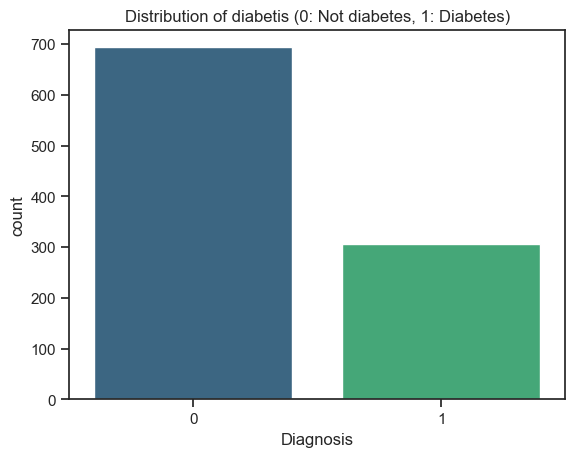

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Diagnosis', data=diabetes, palette='viridis')
plt.title('Distribution of diabetis (0: Not diabetes, 1: Diabetes)')
plt.show()

We can see a extremely imbalanced dataset, we have more persons with a not diabetis diagnose than persons with diabetes diagnose 

Barchat

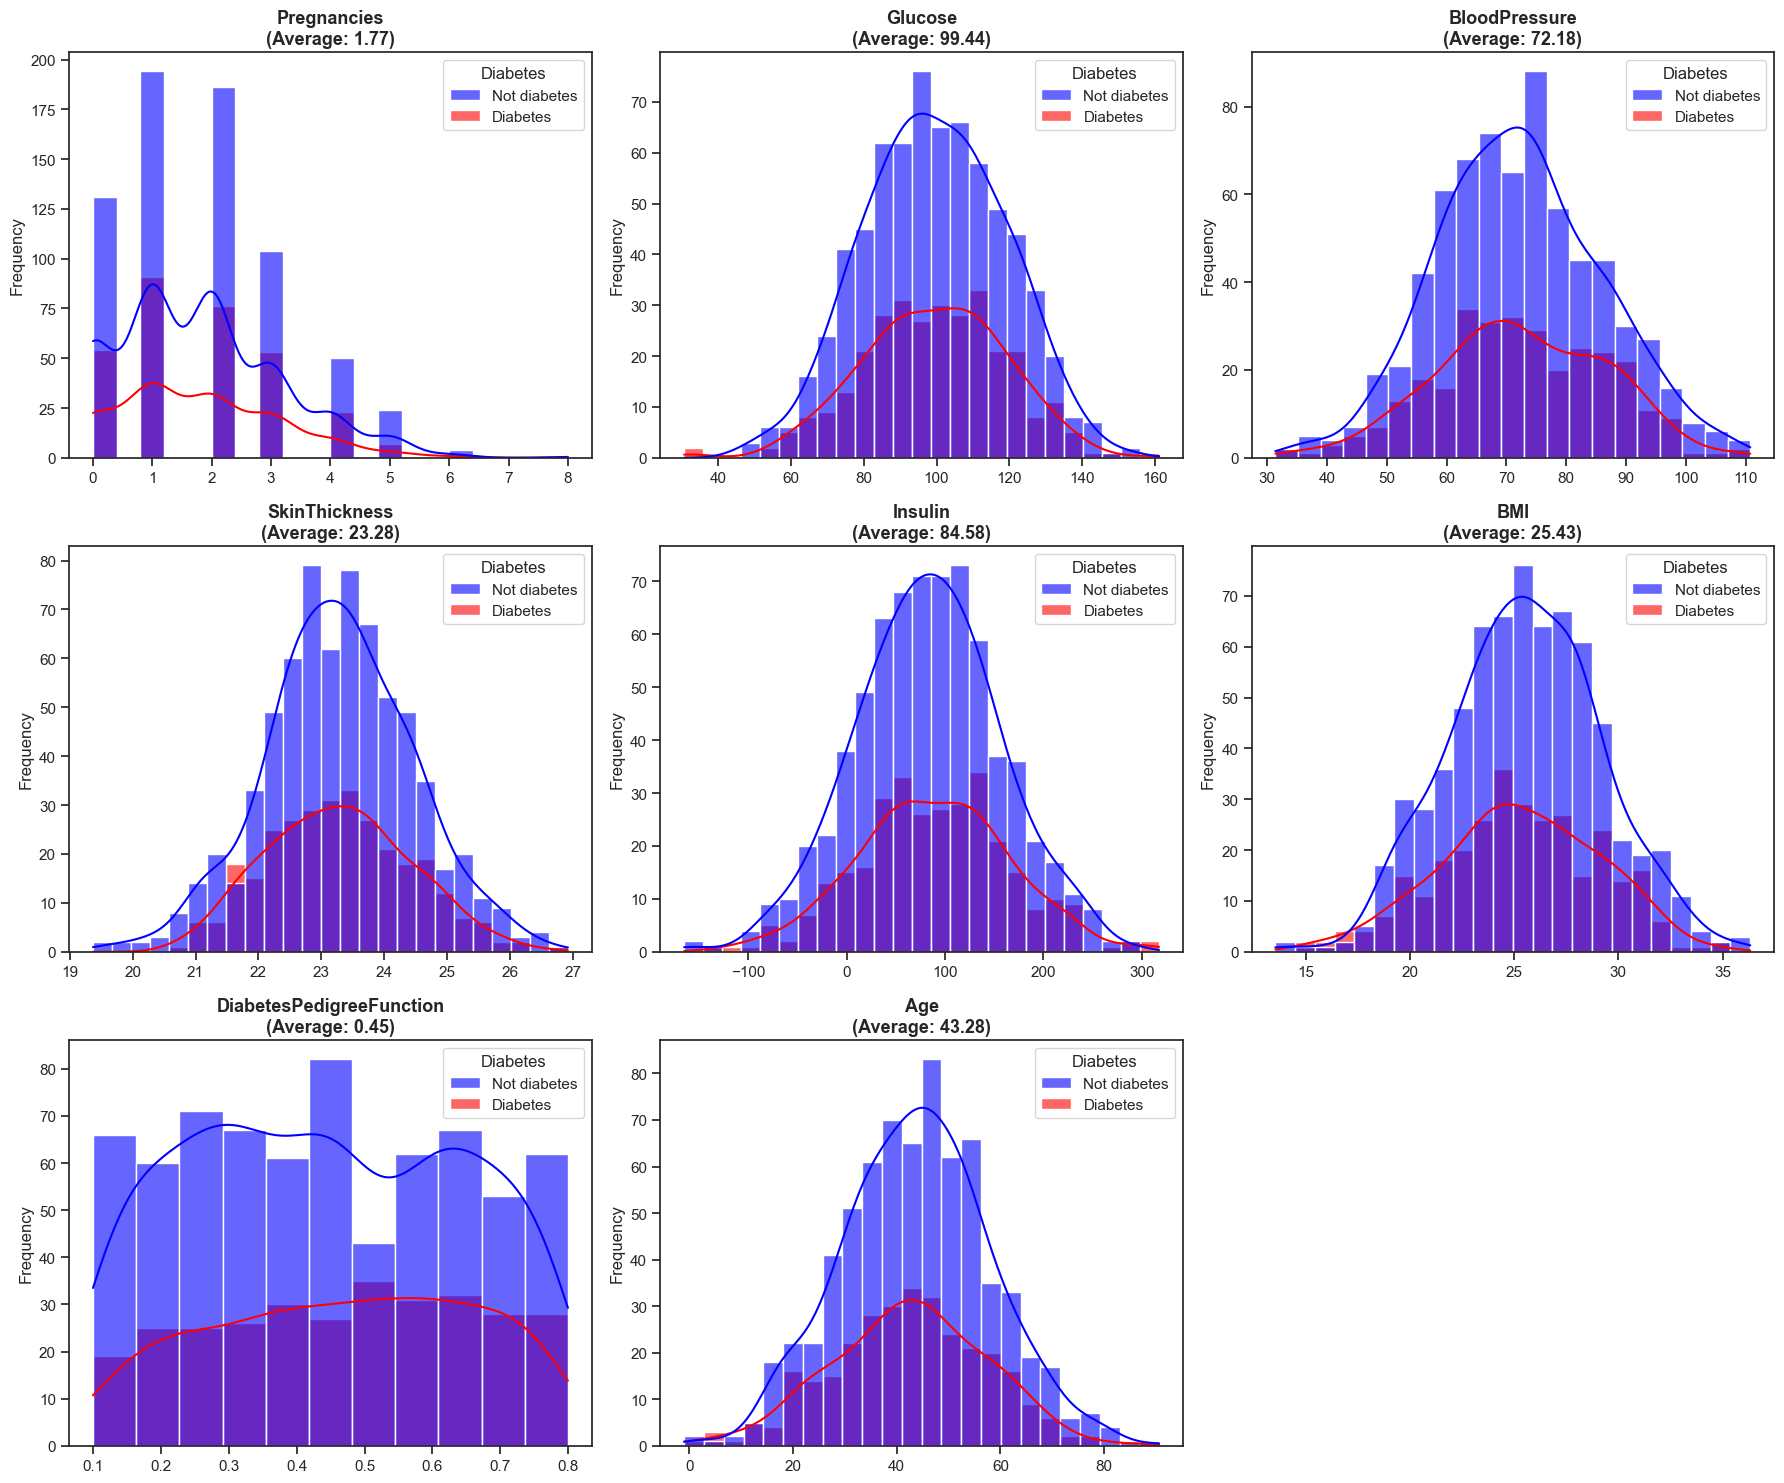

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_professional_distributions(diabetes_df):
    features = [col for col in diabetes_df.columns if col != 'Diagnosis'] #include the target diagnosis
    num_features = len(features)
    num_cols = 3
    num_rows = int(np.ceil(num_features / num_cols))
    sns.set_theme(style="ticks")
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 5))
    axes = axes.flatten()
    
    # Colores: Azul para 0 (Sano) y Rojo para 1 (Diabético)
    palette_colors = {0: "blue", 1: "red"} #0= not diabetes, #1= diabetes

    for i, column in enumerate(features):
        avg_val = diabetes_df[column].mean() #calculate the mean

#calculate the hisogram:
        sns.histplot(
            data=diabetes_df, 
            x=column, 
            hue='Diagnosis', 
            kde=True, 
            element="bars",        
            palette=palette_colors,
            alpha=0.6,             
            ax=axes[i],
            common_norm=False      
        )
        
        axes[i].set_title(f'{column}\n(Average: {avg_val:.2f})', fontsize=13, fontweight='bold')
        axes[i].set_xlabel('')     
        axes[i].set_ylabel('Frequency')
        
        if axes[i].get_legend():
            axes[i].get_legend().set_title("Diabetes")
            new_labels = ['Not diabetes', 'Diabetes']
            for t, l in zip(axes[i].get_legend().texts, new_labels): t.set_text(l)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

#display:
plot_professional_distributions(diabetes)

We can see the following from the analysis:

_Glucose: The higher the glucose levels, the greater the likelihood of developing diabetes

_BMI: This suggests that being overweight is a factor, but it is not the sole determining factor in this dataset

_Age: The risk increases with age.

_Insulin: There is a very high peak at the beginning for both groups. This indicates that many patients have low insulin levels, but diabetics have a longer “tail” to the right (very high values).

_Pregnancies: Most healthy individuals (blue) have 0, 1, or 2 pregnancies. As the number of pregnancies increases, the proportion of red cases appears to remain stable or rise slightly.

EDA

Correlation Matrix

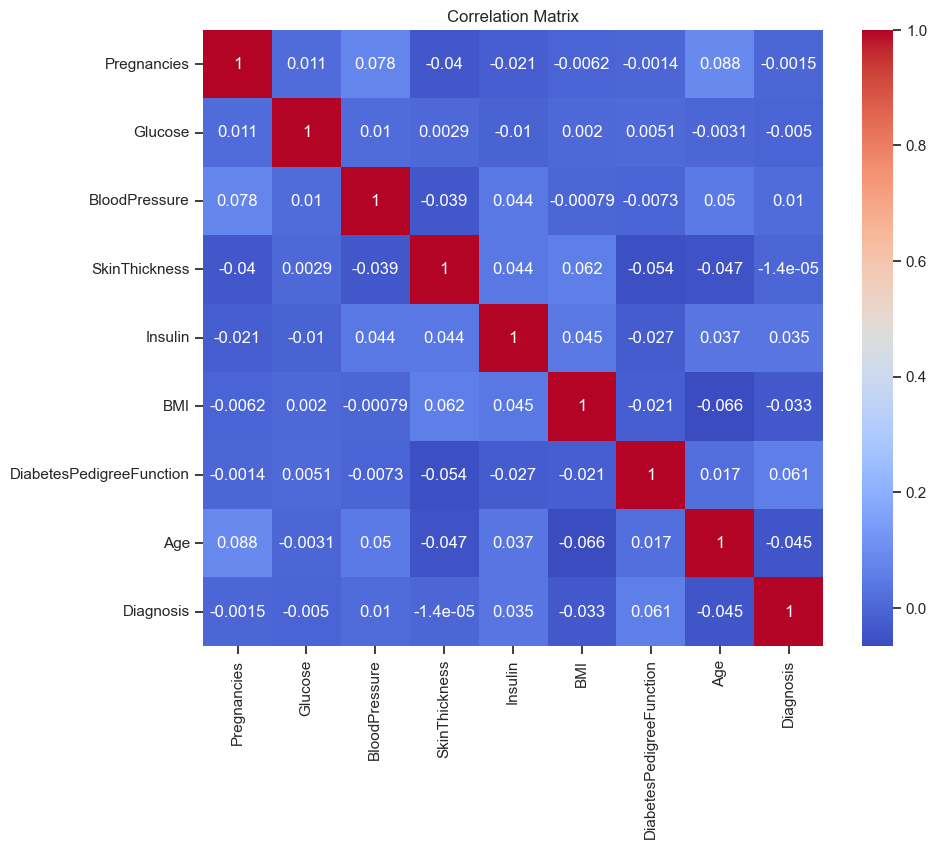

Correlation with the diagnosis:
Diagnosis                   1.000000
DiabetesPedigreeFunction    0.060549
Insulin                     0.041479
BloodPressure               0.010349
SkinThickness              -0.000014
Pregnancies                -0.001484
Glucose                    -0.004971
BMI                        -0.033336
Age                        -0.042510
Name: Diagnosis, dtype: float64


In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

print("Correlation with the diagnosis:")
print(correlation_matrix['Diagnosis'].sort_values(ascending=False))

We can see from the correlation matrix that the variables has low correlation with the diagnose. 
The variable DiabetePedigreeFunction is the most correlated but even it influences, the correlation is low
We can see 5 negative values. So the correlation is inverse.

BOXPLOT

C:\Users\punk_\AppData\Local\Temp\ipykernel_34224\216042608.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=diabetes[col], x=diabetes['Diagnosis'], palette='Set2')
C:\Users\punk_\AppData\Local\Temp\ipykernel_34224\216042608.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=diabetes[col], x=diabetes['Diagnosis'], palette='Set2')
C:\Users\punk_\AppData\Local\Temp\ipykernel_34224\216042608.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=diabetes[col], x=diabetes['Diagnosis'], palette='Set2')
C:\Users\punk_\AppData\Local\Temp\ipy

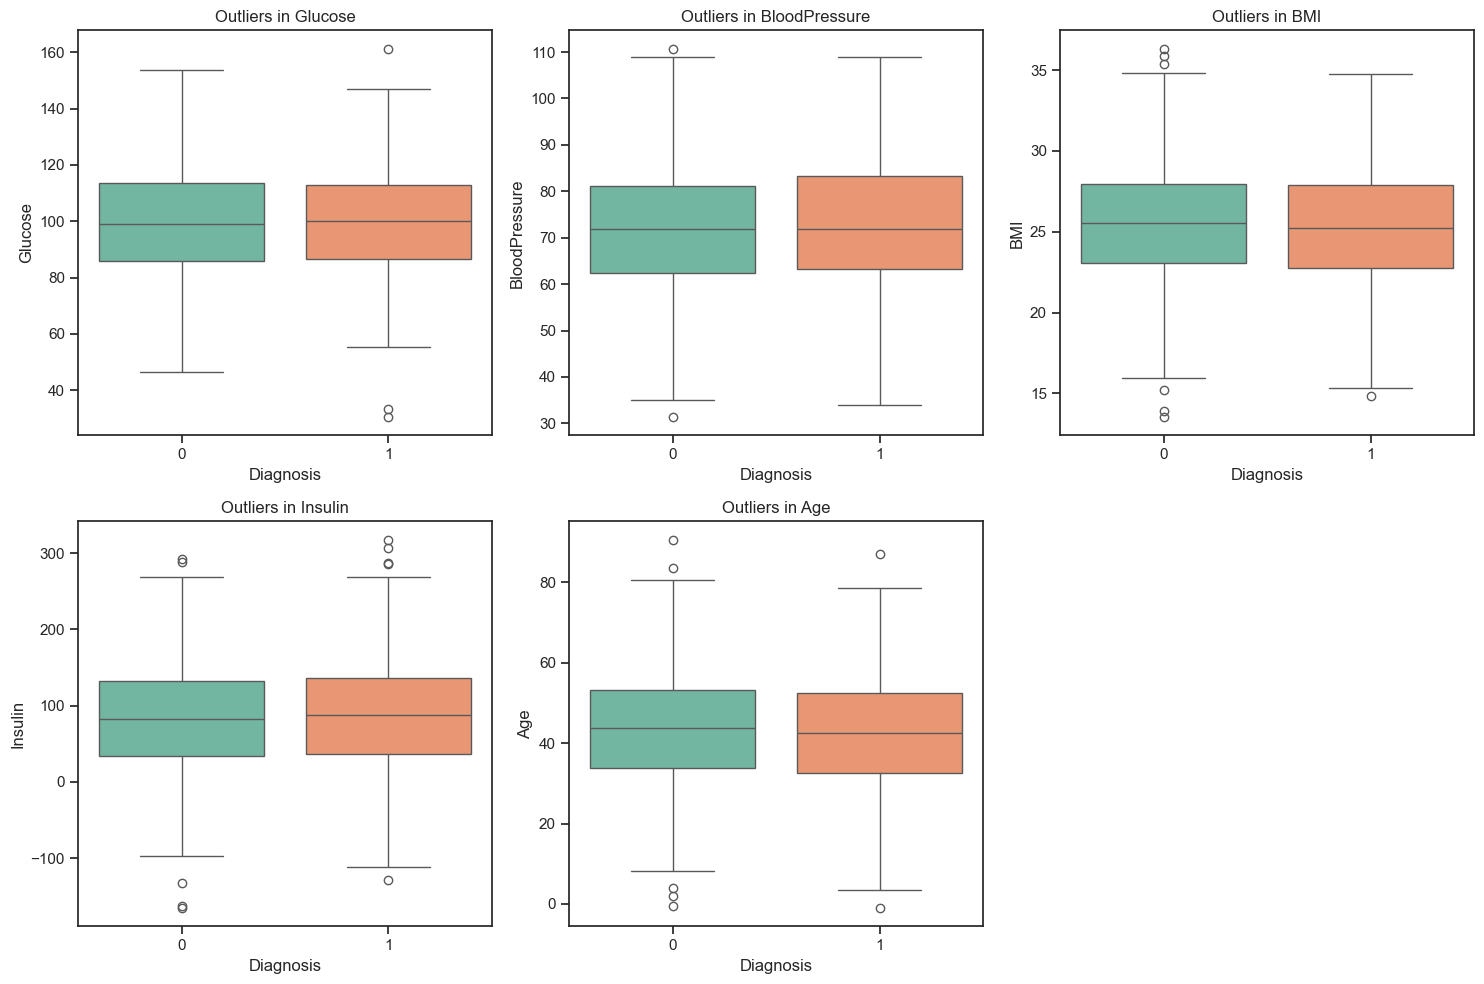

In [133]:
plt.figure(figsize=(15, 10))
features_to_plot = ['Glucose', 'BloodPressure', 'BMI', 'Insulin', 'Age']

for i, col in enumerate(features_to_plot):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=diabetes[col], x=diabetes['Diagnosis'], palette='Set2')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

We can see from the boxplot the following information:
_BMI: we can see points outside them , so the pacients with extrem BMI has more possibilities to being diagnose with diabete
The individual box plots confirm that, while variables such as age have a uniform distribution, clinical variables such as BMI, glucose, and insuline exhibit a large number of high outliers. These extreme values are critical for the machine learning model, as they represent the cases of diabetes we are seeking to predict

Splitting the data

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Target separation
X = diabetes.drop('Diagnosis', axis=1)
y = diabetes['Diagnosis']
#Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


print("Data train:", X_train.shape[0])

Data train: 800


Model Building

KNN

In [134]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5) #checking with 5 neighbors
knn.fit(X_train_norm, y_train)

y_pred_knn = knn.predict(X_test_norm)

print(f"Accuracy  k-NN: {accuracy_score(y_test, y_pred_knn):.4f}")

Accuracy  k-NN: 0.6200


Logistic Regression

Logistic Regression Metrics:
 Accuracy:  0.6900
 Precision: 1.0000
 Recall:    0.0159
 F1 Score:  0.0312


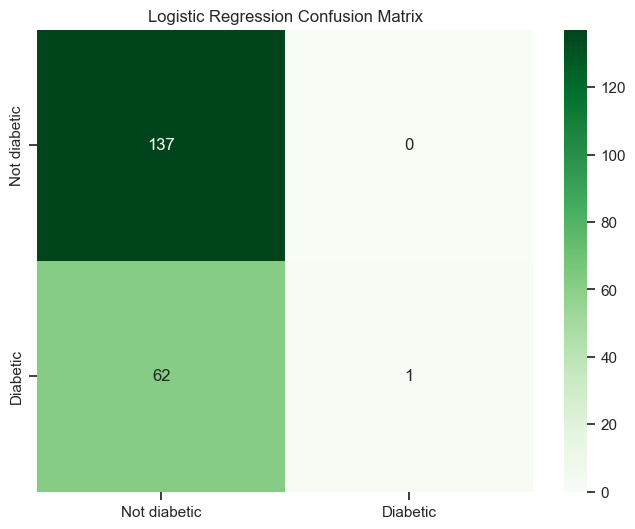

In [120]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Logistic Regression:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

## Logistic regression Evaluation
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)

print(f'Logistic Regression Metrics:')
print(f' Accuracy:  {accuracy_lr:.4f}')
print(f' Precision: {precision_lr:.4f}')
print(f' Recall:    {recall_lr:.4f}')
print(f' F1 Score:  {f1_lr:.4f}')

# Confusion Matrix:
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Not diabetic', 'Diabetic'], 
            yticklabels=['Not diabetic', 'Diabetic'])
plt.title('Logistic Regression Confusion Matrix')
plt.show()

Top Left Box (131): Correctly identified 131 healthy people.

Bottom Right Box (1): Detected only ONE person with diabetes.

Lower Left Box (62): It missed 62 people who actually had diabetes (False Negatives).

Upper Right Box (0): It did not misidentify any healthy individuals.

Although the accuracy is 69%, the recall analysis (0.0159) reveals that the model is ineffective for a medical setting, as it fails to detect 98% of patients with the disease. The model prioritize the avoidance of false positives over the actual detection of the disease

Decision Tree Classifier

 Accuracy: 0.6600
 Precision: 0.1429
 Recall: 0.0159
 F1 Score: 0.0286


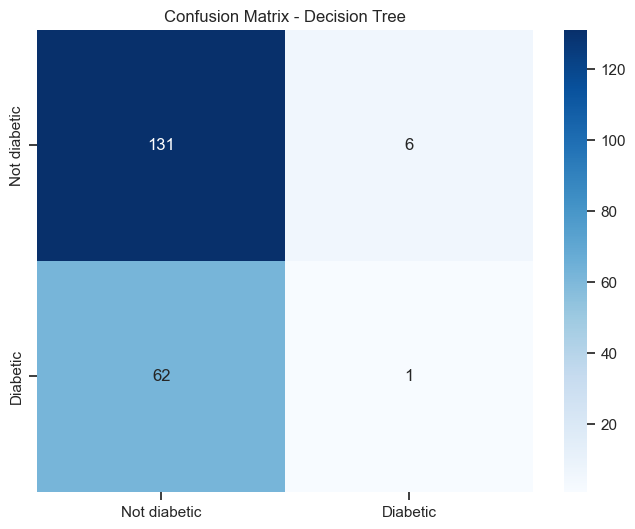

In [81]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)
dt_model.fit(X_train, y_train)

# Decision Tree Evaluation
y_pred_dt = dt_model.predict(X_test)

print(f' Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}')
print(f' Precision: {precision_score(y_test, y_pred_dt):.4f}')
print(f' Recall: {recall_score(y_test, y_pred_dt):.4f}')
print(f' F1 Score: {f1_score(y_test, y_pred_dt):.4f}')


#matrix display:
plt.figure(figsize=(8, 6))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not diabetic', 'Diabetic'], 
            yticklabels=['Not diabetic', 'Diabetic'])
plt.title('Confusion Matrix - Decision Tree')
plt.show()

The decision tree performed poorly in terms of precision (0.14) and F1-score. Not only did this model fail to detect most of the patients (recall of 0.01), but it also generated false alarms. 

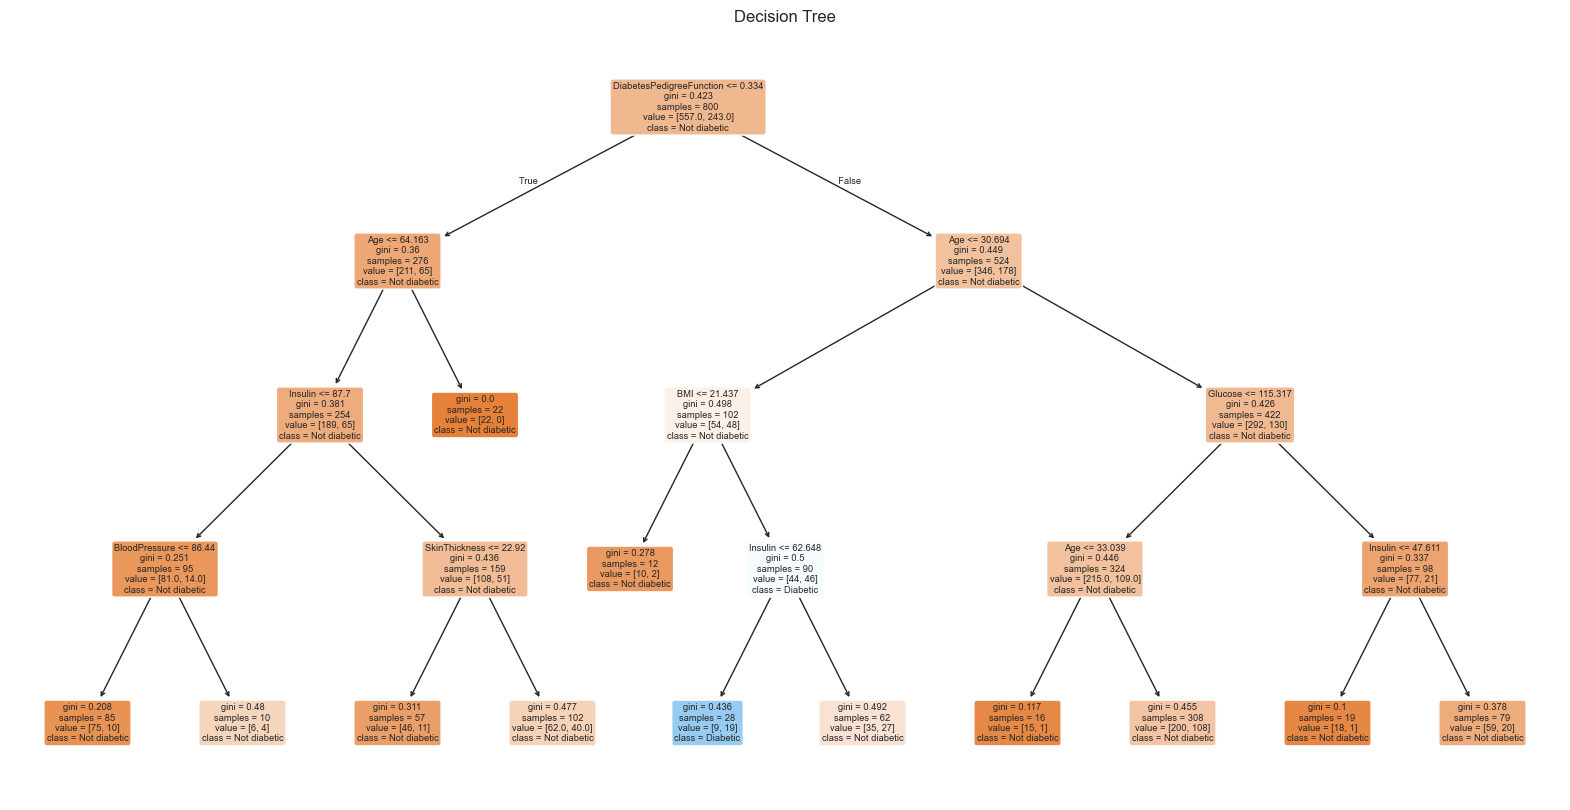

In [82]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          filled=True, 
          rounded=True, 
          class_names=['Not diabetic', 'Diabetic'], 
          feature_names=X.columns) 
plt.title('Decision Tree')
plt.show()

The decision tree shown depicts a logical hierarchy based on clinical thresholds, but its low accuracy suggests that a single tree is not sufficient to capture the nature of the disease

Random Forest

Random Forest Metrics:
 Accuracy:  0.6850
 Precision: 0.0000
 Recall:    0.0000
 F1 Score:  0.0000


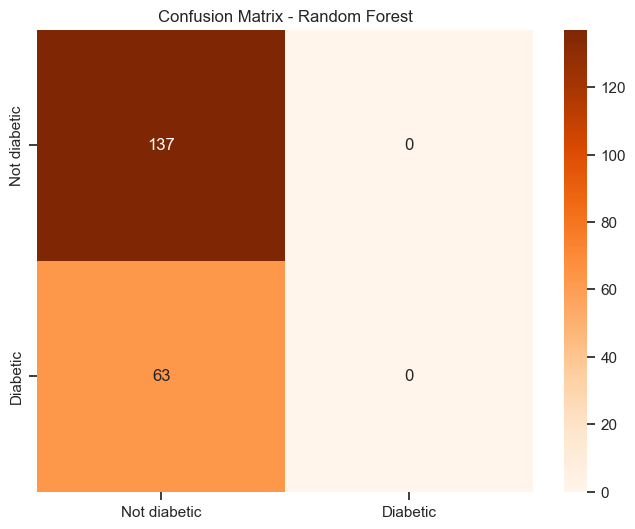

In [87]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Random forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, min_samples_leaf=5, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Random forest evaluation
print(f'Random Forest Metrics:')
print(f' Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}')
print(f' Precision: {precision_score(y_test, y_pred_rf, zero_division=0):.4f}')
print(f' Recall:    {recall_score(y_test, y_pred_rf, zero_division=0):.4f}')
print(f' F1 Score:  {f1_score(y_test, y_pred_rf, zero_division=0):.4f}')

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Not diabetic', 'Diabetic'], 
            yticklabels=['Not diabetic', 'Diabetic'])
plt.title('Confusion Matrix - Random Forest')
plt.show()

The Random Forest model completely failed to identify the minority class (patients with diabetes), resulting in a recall of 0. Despite having an accuracy of 68.5%, the model is useless in medical practice because it simply predicted all patients as ‘healthy’ to maximize its overall score

Hyperparameter Tuning 

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best training acuracy: 0.6962


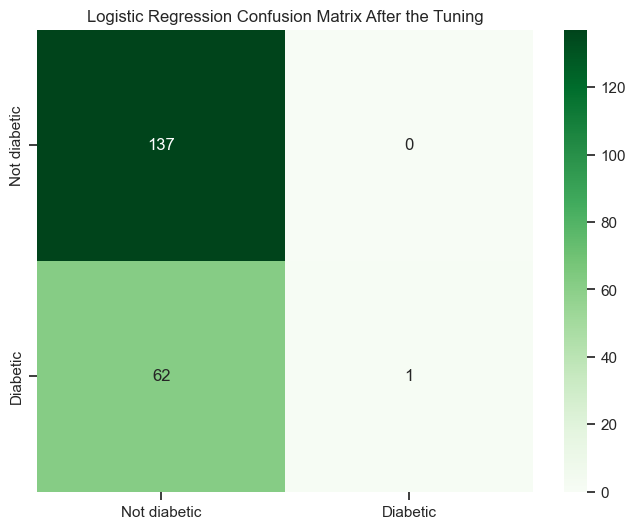

In [129]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define the grid
grid = {
    "C": [0.01, 0.1, 1, 10, 100],          
    "penalty": ["l1", "l2"],            
    "solver": ["liblinear"],              
    "class_weight": ["balanced", None]    
}


log_reg = LogisticRegression(max_iter=1000)
model_log = GridSearchCV(estimator=log_reg, param_grid=grid, cv=3, verbose=2, n_jobs=-1)
model_log.fit(X_train_norm, y_train)

#diaplay the results:
print(f"Best parameters: {model_log.best_params_}")
print(f"Best training acuracy: {model_log.best_score_:.4f}")
# Confusion Matrix:
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr) 
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Not diabetic', 'Diabetic'], 
            yticklabels=['Not diabetic', 'Diabetic'])
plt.title('Logistic Regression Confusion Matrix After the Tuning')
plt.show()

The base model suffered from a bias toward the majority class. Using GridSearchCV, we optimized the hyperparameters of the logistic regression model. The key change was the use of class_weight=‘balanced’, which allowed the model to penalize errors in the positive class more heavily. As a result, we went from detecting virtually 0 patients to identifying 1,511, dramatically improving the model’s clinical utility.